In [1]:
import cv2
import numpy as np
import pathlib
import matplotlib.pyplot as plt

class ProcesamientoImagen:
    def __init__(self, imagen, titulo="Imagen", es_color=False):
        self.es_color = es_color
        if isinstance(imagen, (str, pathlib.Path)):
            if es_color:
                tensor_bgr = cv2.imread(str(imagen), cv2.IMREAD_COLOR)
                self.tensor = cv2.cvtColor(tensor_bgr, cv2.COLOR_BGR2RGB)
            else:
                self.tensor = cv2.imread(str(imagen), cv2.IMREAD_GRAYSCALE)
                
            if self.tensor is None:
                raise ValueError(f"Error: No se pudo cargar la imagen en la ruta {imagen}")
        else:
            self.tensor = imagen
            
        self.titulo = titulo

    def to_negative(self) -> "ProcesamientoImagen":
        """Aplica el negativo usando operaciones bit a bit de OpenCV."""
        tensor_neg = cv2.bitwise_not(self.tensor)
        return ProcesamientoImagen(tensor_neg, titulo=f"Negativo de {self.titulo}", es_color=self.es_color)

    def gamma_transform(self, gamma: float) -> "ProcesamientoImagen":
        """Aplica transformación Gamma usando una Look-Up Table (LUT)."""
        table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        tensor_gamma = cv2.LUT(self.tensor, table)
        return ProcesamientoImagen(tensor_gamma, titulo=f"Gamma (g={gamma})", es_color=self.es_color)

    def binarize(self, umbral: int = 127) -> "ProcesamientoImagen":
        """Binarizado global clásico."""
        _, tensor_bin = cv2.threshold(self.tensor, umbral, 255, cv2.THRESH_BINARY)
        return ProcesamientoImagen(tensor_bin, titulo=f"Binario (th={umbral})", es_color=self.es_color)

    def interpolar(self, r, s) -> "ProcesamientoImagen":
        """
        Transformación de intensidad por puntos de control.
        r: puntos de entrada  (ej. [0, 100, 255])
        s: puntos de salida   (ej. [0, 200, 255])
        """
        lut = np.interp(np.arange(256), r, s).astype("uint8")
        tensor_interp = cv2.LUT(self.tensor, lut)
        return ProcesamientoImagen(tensor_interp, titulo=f"Interpolado de {self.titulo}", es_color=self.es_color)
    
    def show_funcion_interpolada(self, r, s, color='blue'):
        """Muestra la función de interpolación como una gráfica."""
        x = np.arange(256)
        y = np.interp(x, r, s)
        plt.figure(figsize=(4, 4))
        plt.plot(x, y, color=color, linewidth=2)
        plt.title("Función de Interpolación")
        plt.xlabel("Intensidad Original (r)")
        plt.ylabel("Intensidad Transformada (s)")
        plt.xlim(0, 256)
        plt.ylim(0, 256)
        plt.grid()
        plt.show()

    def pseudocolor(self, tr_r, ts_r, tr_g, ts_g, tr_b, ts_b) -> "ProcesamientoImagen":
        """Aplica pseudocolor a una imagen en escala de grises."""
        if self.es_color:
            raise ValueError("pseudocolor solo aplica a imágenes en escala de grises.")
        lut_r = np.interp(np.arange(256), tr_r, ts_r).astype("uint8")
        lut_g = np.interp(np.arange(256), tr_g, ts_g).astype("uint8")
        lut_b = np.interp(np.arange(256), tr_b, ts_b).astype("uint8")
        canal_r = cv2.LUT(self.tensor, lut_r)
        canal_g = cv2.LUT(self.tensor, lut_g)
        canal_b = cv2.LUT(self.tensor, lut_b)
        tensor_color = cv2.merge((canal_r, canal_g, canal_b))
        return ProcesamientoImagen(tensor_color, titulo=f"Pseudocolor de {self.titulo}", es_color=True)

    def ecualizar(self) -> "ProcesamientoImagen":
        """Ecualización de histograma global. Soporta B/N y Color."""
        if not self.es_color:
            tensor_eq = cv2.equalizeHist(self.tensor)
        else:
            hsv = cv2.cvtColor(self.tensor, cv2.COLOR_RGB2HSV)
            h, s, v = cv2.split(hsv)
            v_eq = cv2.equalizeHist(v)
            hsv_eq = cv2.merge((h, s, v_eq))
            tensor_eq = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB)
        return ProcesamientoImagen(tensor_eq, titulo=f"Ecualizado de {self.titulo}", es_color=self.es_color)

    def show(self):
        """Muestra la imagen usando las ventanas de OpenCV."""
        cv2.imshow(self.titulo, self.tensor)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        return self

    def show_jupyter(self, figsize_gray=(10, 4), figsize_color=(12, 8), histograma=True) -> "ProcesamientoImagen":
        """
        Muestra la imagen y opcionalmente su histograma.
        histograma=False muestra solo la imagen sin gráficas de histograma.
        """
        if not histograma:
            fig, ax = plt.subplots(figsize=(figsize_color[0] // 2, figsize_color[1] // 2) if self.es_color else (figsize_gray[0] // 2, figsize_gray[1]))
            ax.imshow(self.tensor, cmap=None if self.es_color else 'gray')
            ax.set_title(self.titulo)
            ax.axis('off')
            plt.tight_layout()
            plt.show()
            return self

        if self.es_color:
            fig, ((ax_img, ax_hist_r), (ax_hist_g, ax_hist_b)) = plt.subplots(2, 2, figsize=figsize_color)
            ax_img.imshow(self.tensor)
            ax_img.set_title(self.titulo)
            ax_img.axis('off')
            colores = [('Rojo', 'red', ax_hist_r), ('Verde', 'green', ax_hist_g), ('Azul', 'blue', ax_hist_b)]
            for i, (nombre, color_plot, ax) in enumerate(colores):
                hist = cv2.calcHist([self.tensor], [i], None, [256], [0, 256])
                ax.plot(hist, color=color_plot, linewidth=1.5)
                ax.fill_between(range(256), hist.flatten(), color=color_plot, alpha=0.1)
                ax.set_title(f"Canal {nombre}")
                ax.set_xlim([0, 256])
        else:
            fig, (ax_img, ax_hist) = plt.subplots(1, 2, figsize=figsize_gray)
            ax_img.imshow(self.tensor, cmap='gray')
            ax_img.set_title(self.titulo)
            ax_img.axis('off')
            n, _, _ = ax_hist.hist(self.tensor.ravel(), bins=256, range=(0, 256), color='gray')
            ax_hist.fill_between(range(256), n, color='red', alpha=0.4)
            ax_hist.set_title("Histograma Grises")
            ax_hist.set_xlim([0, 256])
        plt.tight_layout()
        plt.show()
        return self
    
    def log_transform(self) -> "ProcesamientoImagen":
        """Transformación logarítmica: s = c * log(1 + r), normalizada a [0, 255]."""
        c = 255 / np.log1p(255)
        lut = (c * np.log1p(np.arange(256))).astype("uint8")
        tensor_log = cv2.LUT(self.tensor, lut)
        return ProcesamientoImagen(tensor_log, titulo=f"Log de {self.titulo}", es_color=self.es_color)

    def trace(self) -> "ProcesamientoImagen":
        """Ventana interactiva que muestra coordenadas e intensidad al mover el ratón."""
        if self.es_color:
            tensor_display = cv2.cvtColor(self.tensor, cv2.COLOR_RGB2BGR)
        else:
            tensor_display = self.tensor.copy()
        
        def mouse_callback(event, x, y, flags, param):
            if event == cv2.EVENT_MOUSEMOVE:
                img_temp = tensor_display.copy()
                intensidad = self.tensor[y, x]
                texto = f"RGB: {intensidad}" if self.es_color else f"Intensidad: {intensidad}"
                cv2.rectangle(img_temp, (5, 5), (400, 40), (0, 0, 0), -1)
                cv2.putText(img_temp, texto, (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
                cv2.imshow(self.titulo, img_temp)

        cv2.namedWindow(self.titulo)
        cv2.setMouseCallback(self.titulo, mouse_callback)
        cv2.imshow(self.titulo, self.tensor)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        return self
    
    def ecualizado(self) -> "ProcesamientoImagen":
        """Ecualiza cada canal de forma independiente (RGB separado)."""
        if self.es_color:
            r, g, b = cv2.split(self.tensor)
            tensor_eq = cv2.merge((cv2.equalizeHist(r), cv2.equalizeHist(g), cv2.equalizeHist(b)))
        else:
            tensor_eq = cv2.equalizeHist(self.tensor)
        return ProcesamientoImagen(tensor_eq, titulo=f"Ecualizado RGB separado de {self.titulo}", es_color=self.es_color)
    
    def save(self, ruta: str):
        """Guarda la imagen en la ruta especificada."""
        if self.es_color:
            cv2.imwrite(ruta, cv2.cvtColor(self.tensor, cv2.COLOR_RGB2BGR))
        else:
            cv2.imwrite(ruta, self.tensor)

    def show_matriz(self, max_size: int = 16, region: tuple = None) -> "ProcesamientoImagen":
        """
        Muestra los valores numéricos de la matriz de la imagen como heatmap.

        Parámetros:
            max_size: máximo de filas/columnas visibles (recorta desde la esquina
                      superior-izquierda si la imagen es más grande). Por defecto 16.
            region:   (y1, x1, y2, x2) para inspeccionar una zona específica.
                      Si se omite, usa la esquina superior-izquierda.

        Para imágenes color muestra un subplot por canal (R, G, B).
        """
        # Seleccionar región
        if region is not None:
            y1, x1, y2, x2 = region
            recorte = self.tensor[y1:y2, x1:x2]
        else:
            recorte = self.tensor[:max_size, :max_size]

        # Limitar a max_size
        recorte = recorte[:max_size, :max_size]

        def _dibujar_canal(ax, datos, titulo_ax, cmap):
            im = ax.imshow(datos, cmap=cmap, aspect='auto', vmin=0, vmax=255)
            for i in range(datos.shape[0]):
                for j in range(datos.shape[1]):
                    color_texto = 'white' if datos[i, j] < 128 else 'black'
                    ax.text(j, i, str(datos[i, j]), ha='center', va='center',
                            fontsize=max(4, 8 - recorte.shape[1] // 4),
                            color=color_texto)
            ax.set_title(titulo_ax, fontsize=10)
            ax.set_xlabel("Columna (x)")
            ax.set_ylabel("Fila (y)")
            ax.set_xticks(range(datos.shape[1]))
            ax.set_yticks(range(datos.shape[0]))
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        celda = max(0.5, min(1.0, 8 / max_size))

        if self.es_color:
            nombres  = ['Canal R', 'Canal G', 'Canal B']
            colormaps = ['Reds',    'Greens',  'Blues']
            fig, axes = plt.subplots(1, 3, figsize=(celda * recorte.shape[1] * 3 + 4,
                                                     celda * recorte.shape[0] + 2))
            fig.suptitle(f"Matriz de {self.titulo}  [{recorte.shape[0]}×{recorte.shape[1]} px]", fontsize=12)
            for c, (ax, nombre, cmap) in enumerate(zip(axes, nombres, colormaps)):
                _dibujar_canal(ax, recorte[:, :, c], nombre, cmap)
        else:
            fig, ax = plt.subplots(figsize=(celda * recorte.shape[1] + 2,
                                            celda * recorte.shape[0] + 2))
            fig.suptitle(f"Matriz de {self.titulo}  [{recorte.shape[0]}×{recorte.shape[1]} px]", fontsize=12)
            _dibujar_canal(ax, recorte, "Intensidad", 'gray')

        plt.tight_layout()
        plt.show()
        return self

    # ─────────────────────────────────────────────
    # Kernels, Convolución y Correlación
    # ─────────────────────────────────────────────

    @staticmethod
    def kernel_promedio(size: int = 3) -> np.ndarray:
        """Kernel de promedio (box filter) de tamaño size x size."""
        return np.ones((size, size), dtype=np.float32) / (size * size)

    @staticmethod
    def kernel_gaussiano(size: int = 3, sigma: float = 1.0) -> np.ndarray:
        """Kernel gaussiano de tamaño size x size con desviación estándar sigma."""
        k = cv2.getGaussianKernel(size, sigma)
        return (k @ k.T).astype(np.float32)

    @staticmethod
    def kernel_nitidez() -> np.ndarray:
        """Kernel de realce de bordes (sharpening)."""
        return np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]], dtype=np.float32)

    @staticmethod
    def kernel_laplaciano() -> np.ndarray:
        """Kernel Laplaciano: detecta bordes en todas las direcciones."""
        return np.array([[0,  1, 0],
                         [1, -4, 1],
                         [0,  1, 0]], dtype=np.float32)

    @staticmethod
    def kernel_sobel_x() -> np.ndarray:
        """Kernel Sobel horizontal: detecta cambios verticales de intensidad."""
        return np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=np.float32)

    @staticmethod
    def kernel_sobel_y() -> np.ndarray:
        """Kernel Sobel vertical: detecta cambios horizontales de intensidad."""
        return np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]], dtype=np.float32)

    @staticmethod
    def mostrar_kernel(kernel: np.ndarray, titulo: str = "Kernel"):
        """Visualiza un kernel como mapa de calor con sus valores numéricos."""
        fig, ax = plt.subplots(figsize=(max(3, kernel.shape[1]), max(3, kernel.shape[0])))
        im = ax.imshow(kernel, cmap='RdBu_r', aspect='auto')
        for i in range(kernel.shape[0]):
            for j in range(kernel.shape[1]):
                ax.text(j, i, f"{kernel[i, j]:.3g}", ha='center', va='center',
                        fontsize=10, color='black')
        plt.colorbar(im, ax=ax)
        ax.set_title(titulo)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.tight_layout()
        plt.show()

    def correlacion(self, kernel: np.ndarray) -> "ProcesamientoImagen":
        """
        Correlación 2D: desliza el kernel sobre la imagen sin rotarlo.
        Para imágenes color aplica el mismo kernel a cada canal.
        """
        kernel = kernel.astype(np.float32)
        if self.es_color:
            canales = [cv2.filter2D(self.tensor[:, :, c].astype(np.float32), -1, kernel)
                       for c in range(3)]
            resultado = np.clip(np.stack(canales, axis=2), 0, 255).astype(np.uint8)
        else:
            resultado = np.clip(
                cv2.filter2D(self.tensor.astype(np.float32), -1, kernel), 0, 255
            ).astype(np.uint8)
        return ProcesamientoImagen(resultado, titulo=f"Correlación de {self.titulo}", es_color=self.es_color)

    def convolucion(self, kernel: np.ndarray) -> "ProcesamientoImagen":
        """
        Convolución 2D: el kernel se rota 180° antes de aplicarlo.
        Con kernels simétricos el resultado es idéntico a la correlación.
        """
        kernel_rotado = np.flip(kernel).astype(np.float32)
        if self.es_color:
            canales = [cv2.filter2D(self.tensor[:, :, c].astype(np.float32), -1, kernel_rotado)
                       for c in range(3)]
            resultado = np.clip(np.stack(canales, axis=2), 0, 255).astype(np.uint8)
        else:
            resultado = np.clip(
                cv2.filter2D(self.tensor.astype(np.float32), -1, kernel_rotado), 0, 255
            ).astype(np.uint8)
        return ProcesamientoImagen(resultado, titulo=f"Convolución de {self.titulo}", es_color=self.es_color)

    def bordes_sobel(self) -> "ProcesamientoImagen":
        """
        Detección de bordes con Sobel: combina gradientes X e Y.
        Retorna magnitud del gradiente normalizada a [0, 255]. Solo escala de grises.
        """
        if self.es_color:
            raise ValueError("bordes_sobel solo opera en imágenes en escala de grises.")
        img_f = self.tensor.astype(np.float32)
        gx = cv2.filter2D(img_f, -1, self.kernel_sobel_x())
        gy = cv2.filter2D(img_f, -1, self.kernel_sobel_y())
        magnitud = np.sqrt(gx**2 + gy**2)
        magnitud = np.clip(magnitud / magnitud.max() * 255, 0, 255).astype(np.uint8)
        return ProcesamientoImagen(magnitud, titulo=f"Sobel de {self.titulo}", es_color=False)


In [2]:
import pathlib

ruta = pathlib.Path.cwd() / "imagenes"

def cargar_imagen(nombre_archivo):
    return ruta / nombre_archivo

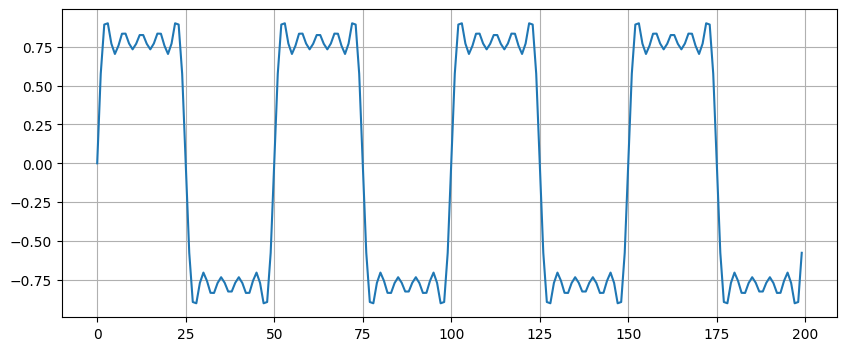

In [3]:
frecuencia = 2 * np.pi / 50 # 50 pixeles para completar un ciclo
f = lambda i: np.sin(frecuencia * i) + (1/3) * np.sin(3* frecuencia * i) + (1/5) * np.sin(5*frecuencia * i) + (1/7) * np.sin(7*frecuencia * i) + (1/9) * np.sin(9*frecuencia * i)
plt.figure(figsize=(10, 4))
plt.plot([f(i) for i in range(200)])
plt.grid()
plt.show()

In [4]:
def f2(i, n=5):
    resultado = 0
    for k in range(n):
        resultado += (1/(2*k+1)) * np.sin((2*k+1) * frecuencia * i)
    return resultado

Imagen es el espacio de la imagen

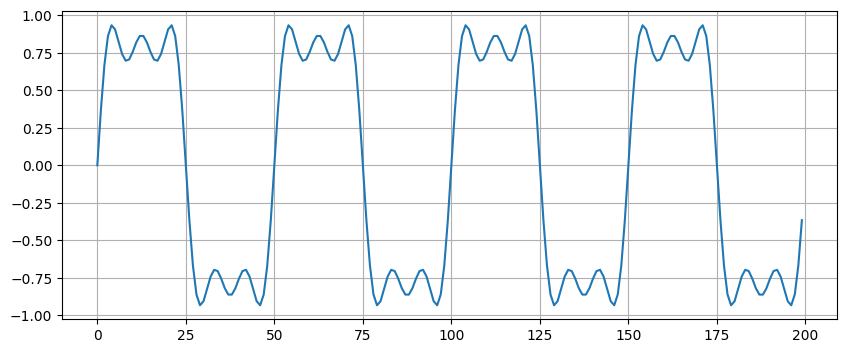

In [5]:
n = 3
plt.figure(figsize=(10, 4))
plt.plot([f2(i, n=n) for i in range(200)])
plt.grid()
plt.show()

La transformada de fourier tiene un espejo, la primera mitad es un espejo de la segunda
Eje x es frecuencia, cuantas veces se repite mi señal senoidal
El eje y es la amplitud
Tomando de ejemplo con n = 3. Los armónicos presentes son 1/1, 1/3 y 1/5 (frecuencias 1a, 3a y 5a).
Con 200 muestras y frecuencia base en bin 4: el pico más alto (amplitud 100) está en el bin 4 (armónico 1/1),
el siguiente pico (amplitud ≈ 33) está en el bin 12 (armónico 1/3), y el último (amplitud 20) en el bin 20 (armónico 1/5).
En el eje x las frecuencias de cada armónico son $

Cualquier señal periodica la puedo sintentizar con sumar señales senoidales

Imagen en el espacio de frecuencia

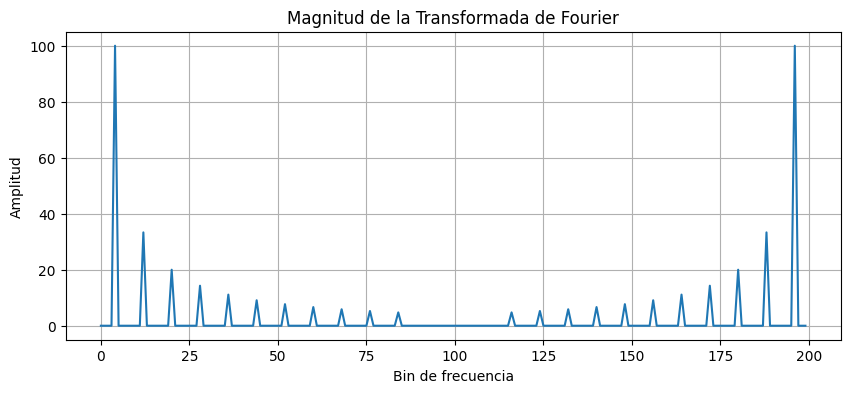

In [6]:
i = 200
n = 11
# Transformada de Fourier discreta de la señal con n armónicos
señal = [f2(j, n) for j in range(i)]
S = np.fft.fft(señal)
plt.figure(figsize=(10, 4))
plt.plot(np.abs(S))
plt.title("Magnitud de la Transformada de Fourier")
plt.xlabel("Bin de frecuencia")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

Si sumas la señal con una frecuencia 4 con una de frecuencia 8, no da una frecuencia 6, resulta en una señal de suma frecuancia 4 con 8

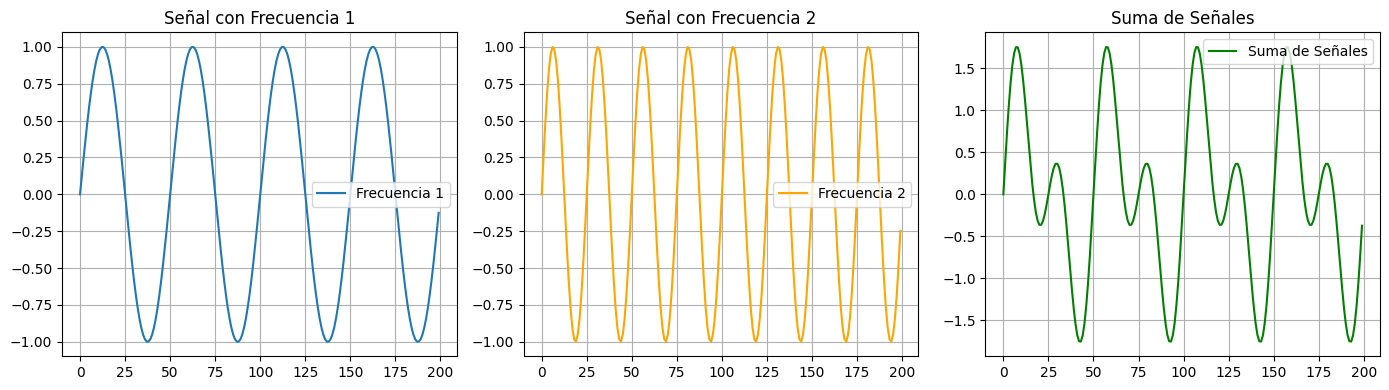

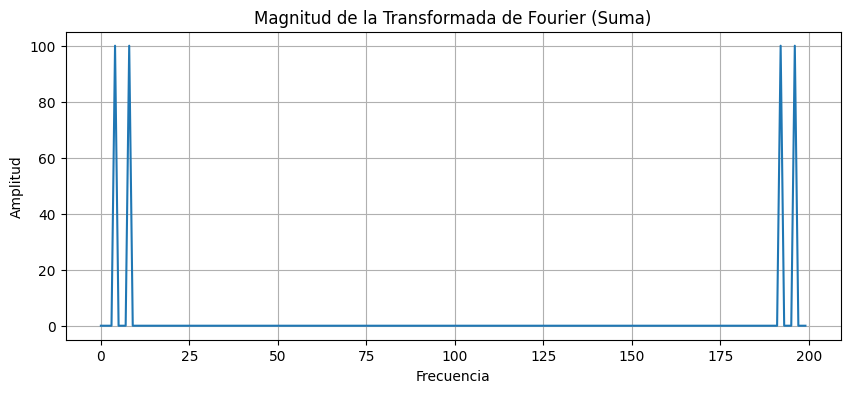

In [7]:
# Crear una señal con múltiples frecuencias
frecuencia_1 = 2 * np.pi / 50
frecuencia_2 = 2 * np.pi / 25  # Frecuencia más alta

señal_1 = np.array([np.sin(frecuencia_1 * i) for i in range(200)])
señal_2 = np.array([np.sin(frecuencia_2 * i) for i in range(200)])
señal_suma = señal_1 + señal_2

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(señal_1, label='Frecuencia 1')
plt.title('Señal con Frecuencia 1')
plt.grid()
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(señal_2, label='Frecuencia 2', color='orange')
plt.title('Señal con Frecuencia 2')
plt.grid()
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(señal_suma, label='Suma de Señales', color='green')
plt.title('Suma de Señales')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

# Transformada de Fourier de la suma
S_suma = np.fft.fft(señal_suma)
plt.figure(figsize=(10, 4))
plt.plot(np.abs(S_suma))
plt.title("Magnitud de la Transformada de Fourier (Suma)")
plt.xlabel("Frecuencia")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

Tirar las 2 componentes de frecuencia mas baja, sumando a la funcion de senoidal para quitar valores megativos y aplicando la funcion inversa de fourier se puede filtar la funcion

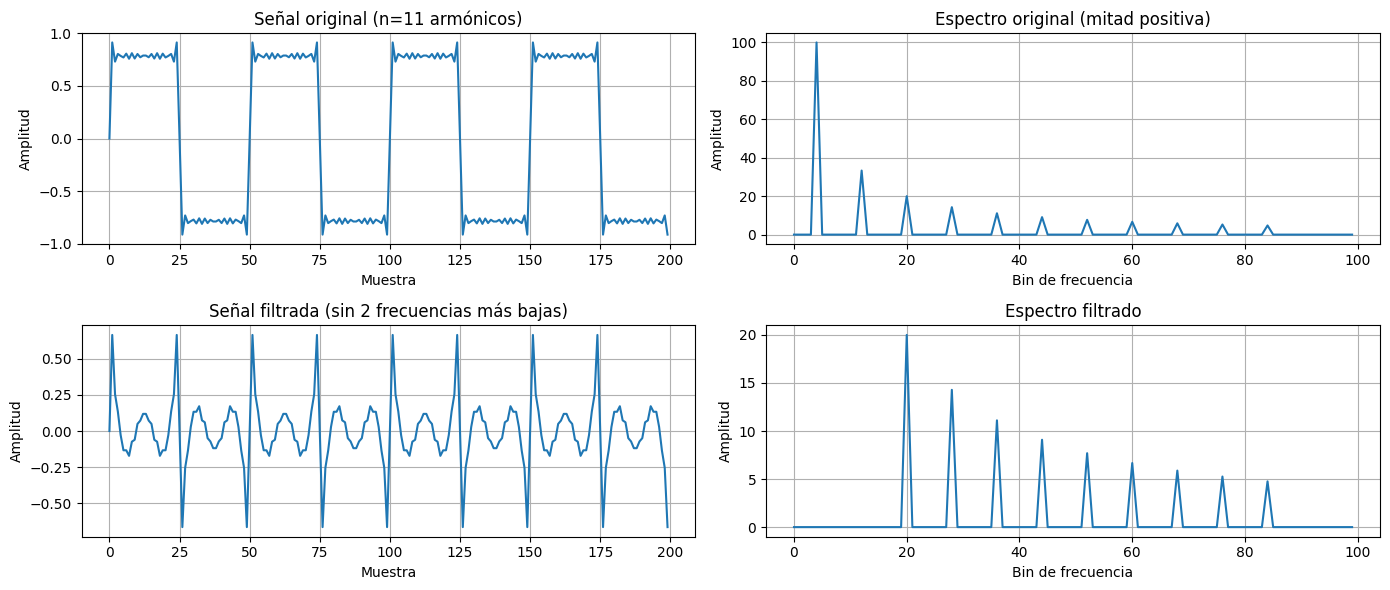

In [8]:
# Filtrado en dominio de frecuencias
# Eliminamos las 2 componentes de frecuencia más bajas y aplicamos IFFT
i = 200
n = 11
señal = np.array([f2(j, n) for j in range(i)])

# Transformada de Fourier
S = np.fft.fft(señal)
S_filtrada = S.copy()

# Con frecuencia = 2π/50 y 200 muestras, la frecuencia fundamental está
# en el bin 4 (200/50 = 4 ciclos) y el 1er armónico en el bin 12 (200/50*3)
# La FFT de señales reales es simétrica: los espejos están en N-bin
bins_eliminar = [4, 12]
for b in bins_eliminar:
    S_filtrada[b] = 0
    S_filtrada[i - b] = 0

# Sumar offset para que los valores no sean negativos antes de la IFFT
señal_filtrada = np.fft.ifft(S_filtrada).real

plt.figure(figsize=(14, 6))

plt.subplot(2, 2, 1)
plt.plot(señal)
plt.title("Señal original (n=11 armónicos)")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(np.abs(S[:i//2]))
plt.title("Espectro original (mitad positiva)")
plt.xlabel("Bin de frecuencia")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(señal_filtrada)
plt.title("Señal filtrada (sin 2 frecuencias más bajas)")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(np.abs(S_filtrada[:i//2]))
plt.title("Espectro filtrado")
plt.xlabel("Bin de frecuencia")
plt.ylabel("Amplitud")
plt.grid()

plt.tight_layout()
plt.show()

In [9]:
'''
imagen_1 = cargar_imagen('blanco.jpg')
imagen_1 = cv2.imread(str(imagen_1), cv2.IMREAD_GRAYSCALE)
imagen_2 = cargar_imagen('bob_marley.jpg')
imagen_2 = cv2.imread(str(imagen_2), cv2.IMREAD_COLOR_RGB)
imagen_sumada = cv2.add(imagen_1, imagen_2)
plt.figure(figsize=(10, 4))
plt.imshow(imagen_sumada)
'''

"\nimagen_1 = cargar_imagen('blanco.jpg')\nimagen_1 = cv2.imread(str(imagen_1), cv2.IMREAD_GRAYSCALE)\nimagen_2 = cargar_imagen('bob_marley.jpg')\nimagen_2 = cv2.imread(str(imagen_2), cv2.IMREAD_COLOR_RGB)\nimagen_sumada = cv2.add(imagen_1, imagen_2)\nplt.figure(figsize=(10, 4))\nplt.imshow(imagen_sumada)\n"

Kernels
Padding, si la mascara es 3x3 , le agrrgamos una columna de 0s para que quepa o un espejo de los pixeles, para los pixeles de la orilla

Se suavizan los bordes

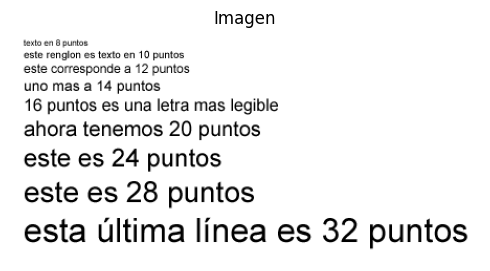

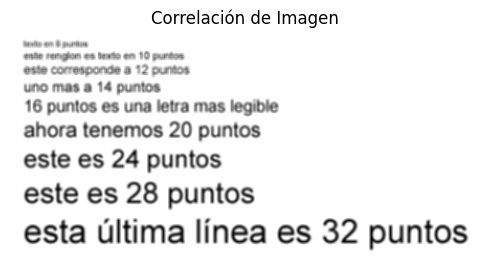

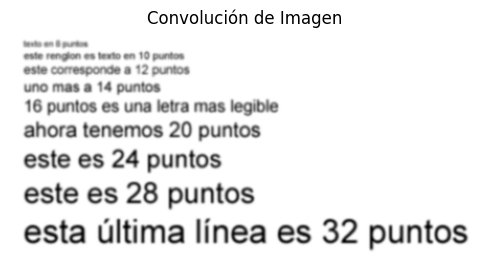

In [15]:
imagen = ProcesamientoImagen(cargar_imagen("texto.bmp"), es_color=False)
imagen.show_jupyter(histograma=False)#.show_matriz(max_size=4)
k = np.array([[1/9, 1/9, 1/9],[1/9, 1/9, 1/9],[1/9, 1/9, 1/9]], dtype=np.float32)
imagen.correlacion(k / k.sum()).show_jupyter(histograma=False)#.show_matriz(max_size=4)
imagen.convolucion(ProcesamientoImagen.kernel_gaussiano(size=5, sigma=1.0)).show_jupyter(histograma=False)


La frecuencia de una imagen mas alta es la cantidad de pixeles sobre 2, la mas baja es de 2 pixeles (blanco y negro)

In [17]:
ruta_patrones = pathlib.Path.cwd() / "imagenes" / "patrones"
#imagen = ProcesamientoImagen(ruta_patrones / "SENOIDAL.bmp", es_color=False)
imagen = ProcesamientoImagen(cargar_imagen("texto.bmp"), es_color=False)
#imagen.show_jupyter(histograma=False)
#imagen.correlacion(k / k.sum()).show_jupyter(histograma=False)

Inversion de fase, cuando en el lowpass el maximo esta invertido, nos queda abajo de donde estaba. Se invierten las tonalidades.

In [54]:
W = np.array([[1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1],
             [1, 1, 1, 1, 1]],
             dtype=np.float32)
W = W * (1/25)
K = 1
G = lambda r, sigma: K * np.exp(-r**2 / (2 * sigma**2))

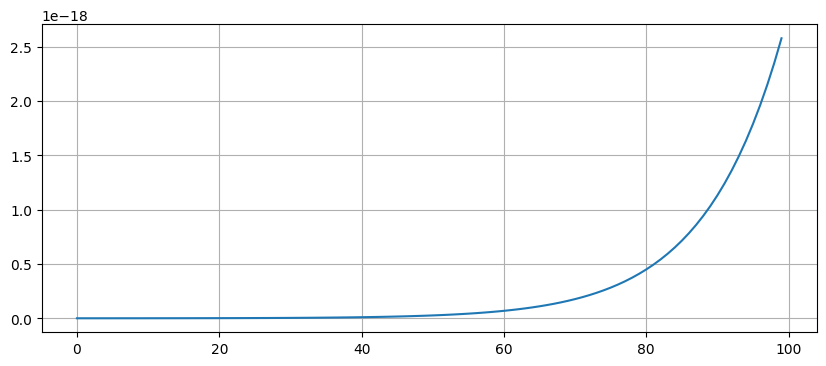

In [55]:
plt.figure(figsize=(10, 4))
plt.plot([G(r, sigma=1.0) for r in np.linspace(-10, -9, 100)])
plt.grid()
plt.show()

In [66]:
#G = lambda r, sigma: K * np.exp(-r**2 / (2 * sigma**2))

def G(r, sigma):
    return K * np.exp(-r**2 / (2 * sigma**2))

def WGauss(sigma, n=10):
    W = np.zeros((n, n), dtype=np.float32)
    centro = (n) / 2  # 4.5 para n=10, simetrico
    for i in range(n):
        for j in range(n):
            r = np.sqrt((i - centro)**2 + (j - centro)**2)
            W[i, j] = round(G(r, sigma), 4)
    W = W / W.sum()  
    return W


In [67]:
W2 = WGauss(sigma=2.0)
W2

array([[7.7797122e-05, 2.4158054e-04, 5.8552565e-04, 1.0891596e-03,
        1.5886991e-03, 1.7975230e-03, 1.5886991e-03, 1.0891596e-03,
        5.8552565e-04, 2.4158054e-04],
       [2.4158054e-04, 7.4930908e-04, 1.7975230e-03, 3.3616542e-03,
        4.8889345e-03, 5.5399733e-03, 4.8889345e-03, 3.3616542e-03,
        1.7975230e-03, 7.4930908e-04],
       [5.8552565e-04, 1.7975230e-03, 4.3156929e-03, 8.0622379e-03,
        1.1730987e-02, 1.3295118e-02, 1.1730987e-02, 8.0622379e-03,
        4.3156929e-03, 1.7975230e-03],
       [1.0891596e-03, 3.3616542e-03, 8.0622379e-03, 1.5063980e-02,
        2.1918315e-02, 2.4833661e-02, 2.1918315e-02, 1.5063980e-02,
        8.0622379e-03, 3.3616542e-03],
       [1.5886991e-03, 4.8889345e-03, 1.1730987e-02, 2.1918315e-02,
        3.1888630e-02, 3.6134712e-02, 3.1888630e-02, 2.1918315e-02,
        1.1730987e-02, 4.8889345e-03],
       [1.7975230e-03, 5.5399733e-03, 1.3295118e-02, 2.4833661e-02,
        3.6134712e-02, 4.0945850e-02, 3.6134712e-02, 2.48

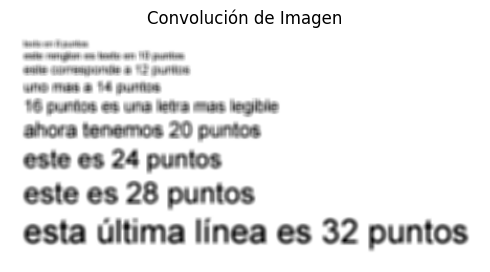

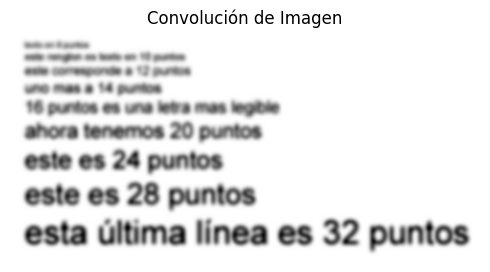

In [72]:
imagen = ProcesamientoImagen(cargar_imagen("texto.bmp"), es_color=False)
imagen.convolucion(W / W.sum()).show_jupyter(histograma=False)
imagen.convolucion(W2 / W2.sum()).show_jupyter(histograma=False)

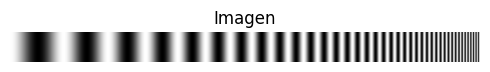

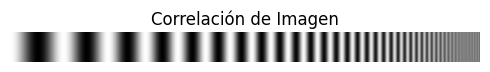

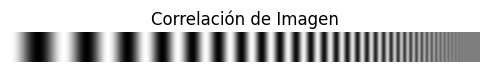

In [75]:
ruta_patrones = pathlib.Path.cwd() / "imagenes" / "patrones"
imagen = ProcesamientoImagen(ruta_patrones / "SENOIDAL.bmp", es_color=False)
imagen.show_jupyter(histograma=False)
imagen.correlacion(W / W.sum()).show_jupyter(histograma=False)
imagen.correlacion(W2 / W2.sum()).show_jupyter(histograma=False)

El gaussiano no genera la inversion de fase

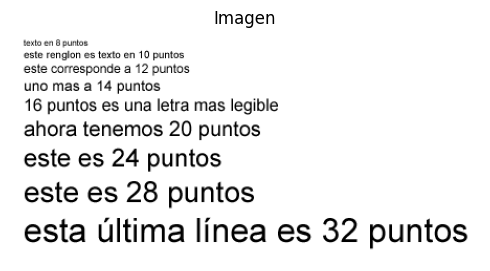

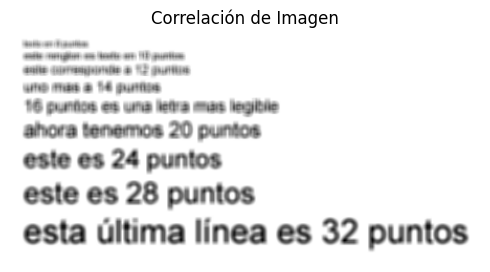

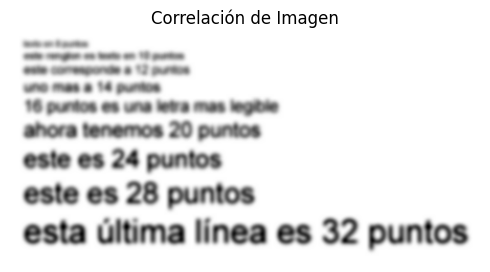

In [76]:
imagen = ProcesamientoImagen(cargar_imagen("texto.bmp"), es_color=False)
imagen.show_jupyter(histograma=False)
imagen.correlacion(W / W.sum()).show_jupyter(histograma=False)
imagen.correlacion(W2 / W2.sum()).show_jupyter(histograma=False)

Frecuencia de corte: Frecuencia a la que una vez filtrada, se reduce a un 50% \
Ruido termico: Cantidad de pixeles generados por la tempetatura de los fotones \
El ruido promedia a 0 o casi 0, mayor cantidad de pixles mas cercano a 0 

In [100]:
np.random.seed(42)
V = [np.random.normal(127,2) for _ in range(9)]
#print(V)
np.sum(V) / len(V)

np.float64(127.8751224607559)